### 1. Environment Setup & Imports

This block consolidates all required libraries for our Exploratory Data Analysis. Setting a consistent plotting style ensures our graphs are clear and professional.

In [1]:
# --- Standard Data Libraries ---
import pandas as pd
import numpy as np

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")

### 2. Data Loading and Initial Inspection

We are loading the AI4I 2020 Predictive Maintenance dataset from the `data/` directory. This step verifies the tabular structure, feature data types, and ensures there are no missing values before we begin modeling.

In [2]:
# Load the dataset based on the current workspace structure
file_path = './data/ai4i2020.csv'
df = pd.read_csv(file_path)

# Display dataset dimensions and the first 5 rows
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")
display(df.head())

# Check for null values and datatypes
print("\n--- Dataset Info ---")
df.info()

Dataset Shape: 10000 rows and 14 columns.



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3

### 3. Target Variable Analysis: Failure Modes

The dataset tracks a general `Machine failure` flag alongside 5 specific failure modes: 
*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failures

Understanding the distribution of these specific faults is critical for our classification model.

C:\Users\Arjun V P\AppData\Local\Temp\ipykernel_11632\3776795273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Reds_r')


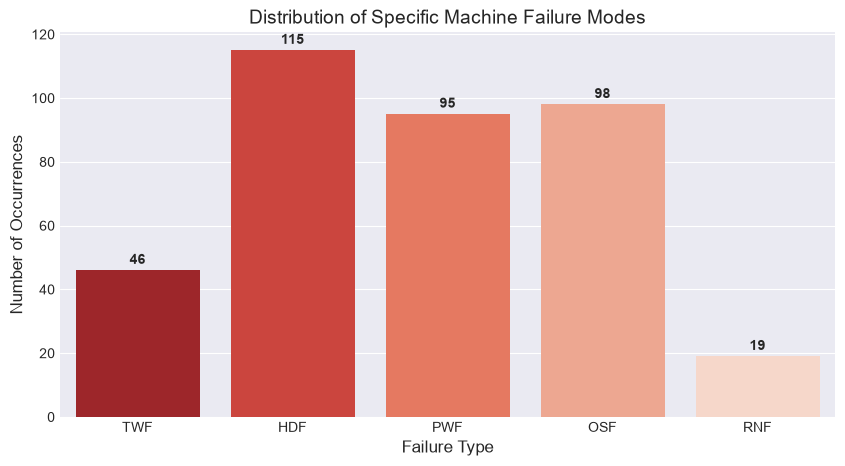

Total operational rows: 9661
Total failure rows: 339


In [3]:
# Isolate the specific failure mode columns
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_modes].sum()

# Plot the distribution
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Reds_r')
plt.title('Distribution of Specific Machine Failure Modes', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Failure Type', fontsize=12)

# Add exact count labels above each bar
for i, v in enumerate(failure_counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

# Compare against the overall failure flag
total_failures = df['Machine failure'].sum()
print(f"Total operational rows: {len(df) - total_failures}")
print(f"Total failure rows: {total_failures}")

### 4. Sensor Feature Correlation

Before training our XGBoost model, we must understand how the continuous sensor features relate to one another. Highly correlated features (like Torque and Rotational Speed) represent the physical constraints of the machinery.

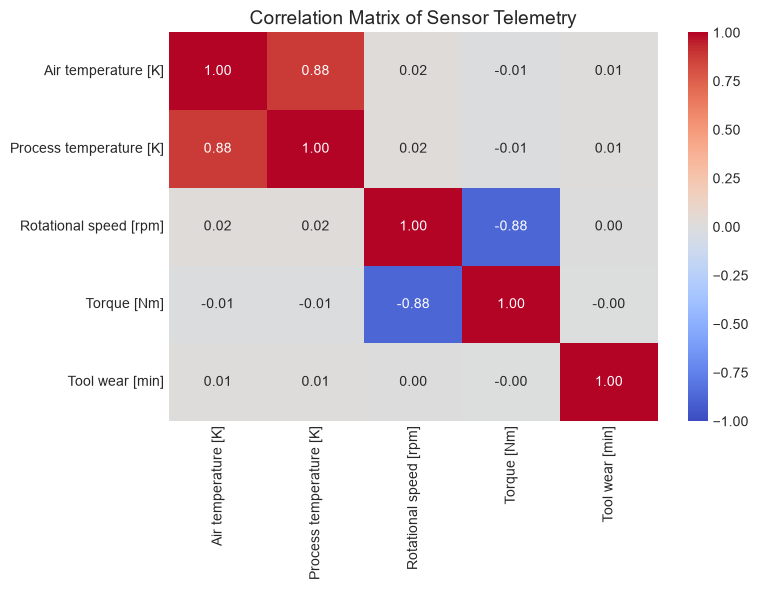

In [4]:
# Select only the continuous physical sensor features
sensor_features = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

# Calculate the correlation matrix
corr_matrix = df[sensor_features].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Sensor Telemetry', fontsize=14)
plt.tight_layout()
plt.show()

### 5. Feature Behavior During Failures: Torque vs. RPM

Since mechanical power is a product of Torque and Rotational Speed, failures like Overstrain (OSF) and Power Failures (PWF) often cluster at the extreme ends of these two metrics. This scatter plot helps visualize the decision boundary our XGBoost model will need to learn.

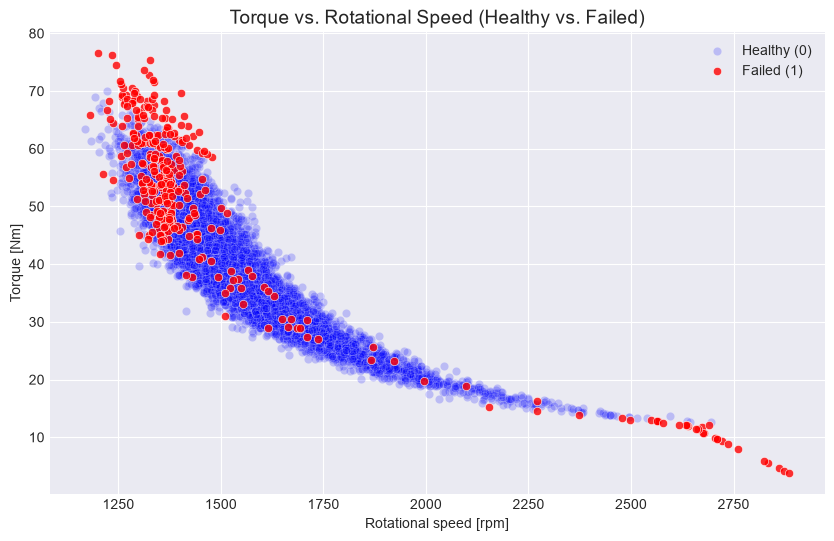

In [5]:
plt.figure(figsize=(10, 6))

# Plot healthy machines
sns.scatterplot(
    data=df[df['Machine failure'] == 0], 
    x='Rotational speed [rpm]', 
    y='Torque [Nm]', 
    color='blue', 
    alpha=0.2, 
    label='Healthy (0)'
)

# Plot failed machines on top
sns.scatterplot(
    data=df[df['Machine failure'] == 1], 
    x='Rotational speed [rpm]', 
    y='Torque [Nm]', 
    color='red', 
    alpha=0.8, 
    label='Failed (1)'
)

plt.title('Torque vs. Rotational Speed (Healthy vs. Failed)', fontsize=14)
plt.legend()
plt.show()

### 6. Data Preprocessing for XGBoost

Machine learning models require numerical inputs. We will:
1. Drop non-predictive columns (`UDI`, `Product ID`).
2. Encode the `Type` column (Quality variant: L=Low, M=Medium, H=High) into numerical values.
3. Separate our physical features (X) from our target failure modes (y).

In [6]:
from sklearn.preprocessing import LabelEncoder

# Create a copy for modeling
df_model = df.copy()

# 1. Drop irrelevant identifiers
df_model = df_model.drop(['UDI', 'Product ID'], axis=1)

# 2. Encode the 'Type' column (L, M, H)
le = LabelEncoder()
df_model['Type'] = le.fit_transform(df_model['Type'])

print("Encoded 'Type' mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Define Features (X)
# We drop the specific failure modes and the general flag from the input features
X = df_model.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

# 4. Define Target (y)
# For our multi-class diagnostic system, we need to predict the exact failure mode.
# We will create a single target column that represents the specific fault.
def get_failure_type(row):
    if row['TWF'] == 1: return 'TWF'
    if row['HDF'] == 1: return 'HDF'
    if row['PWF'] == 1: return 'PWF'
    if row['OSF'] == 1: return 'OSF'
    if row['RNF'] == 1: return 'RNF'
    return 'Healthy'

df_model['Fault_Class'] = df_model.apply(get_failure_type, axis=1)
y = df_model['Fault_Class']

print("\n--- Final Feature Set (X) ---")
display(X.head(3))
print(f"\nTarget Variable (y) distribution:\n{y.value_counts()}")

Encoded 'Type' mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

--- Final Feature Set (X) ---


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5



Target Variable (y) distribution:
Fault_Class
Healthy    9652
HDF         115
PWF          91
OSF          78
TWF          46
RNF          18
Name: count, dtype: int64
